In [ ]:
import pandas as pd

result_df = pd.read_csv('results_20250204.csv')

# Figure 7: Sensitivity vs Specificity with Pareto Front

In [2]:
result_df

,data,model,sum_epts,calibrate,include_clinical,accuracy,accuracy_std,f1,f1_std,log_loss,...,aupr_std,sensitivity,sensitivity_std,specificity,specificity_std,brier,brier_std,mcc,mcc_std,Unnamed: 25
0,epts,logistic,NaN,NaN,NaN,0.625,0.083,0.147,0.051,0.631,...,0.049,0.609,0.236,0.642,0.139,0.219,0.010,0.117,0.069,NaN
1,epts,logistic,NaN,NaN,--include_clinical,0.626,0.082,0.149,0.060,0.682,...,0.049,0.588,0.255,0.664,0.145,0.244,0.002,0.119,0.074,NaN
2,epts,logistic,NaN,--calibrate,NaN,0.619,0.071,0.141,0.056,0.632,...,0.049,0.655,0.259,0.584,0.200,0.214,0.028,0.114,0.064,NaN
3,epts,logistic,NaN,--calibrate,--include_clinical,0.606,0.079,0.140,0.060,0.647,...,0.049,0.600,0.291,0.613,0.215,0.217,0.031,0.105,0.074,NaN
4,epts,logistic,--sum_epts,NaN,NaN,0.615,0.076,0.147,0.064,0.668,...,0.048,0.607,0.253,0.624,0.182,0.238,0.005,0.113,0.074,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,epts&mri,balanced_random_forest,NaN,--calibrate,--include_clinical,0.556,0.085,0.108,0.103,0.269,...,0.073,0.243,0.274,0.869,0.170,0.068,0.019,0.068,0.109,NaN
92,epts&mri,balanced_random_forest,--sum_epts,NaN,NaN,0.538,0.081,0.103,0.158,0.249,...,0.131,0.108,0.174,0.969,0.034,0.062,0.013,0.078,0.161,NaN
93,epts&mri,balanced_random_forest,--sum_epts,NaN,--include_clinical,0.563,0.101,0.127,0.142,0.311,...,0.105,0.187,0.237,0.939,0.058,0.086,0.017,0.097,0.149,NaN
94,epts&mri,balanced_random_forest,--sum_epts,--calibrate,NaN,0.591,0.098,0.164,0.127,0.254,...,0.131,0.316,0.279,0.867,0.193,0.066,0.018,0.128,0.135,NaN


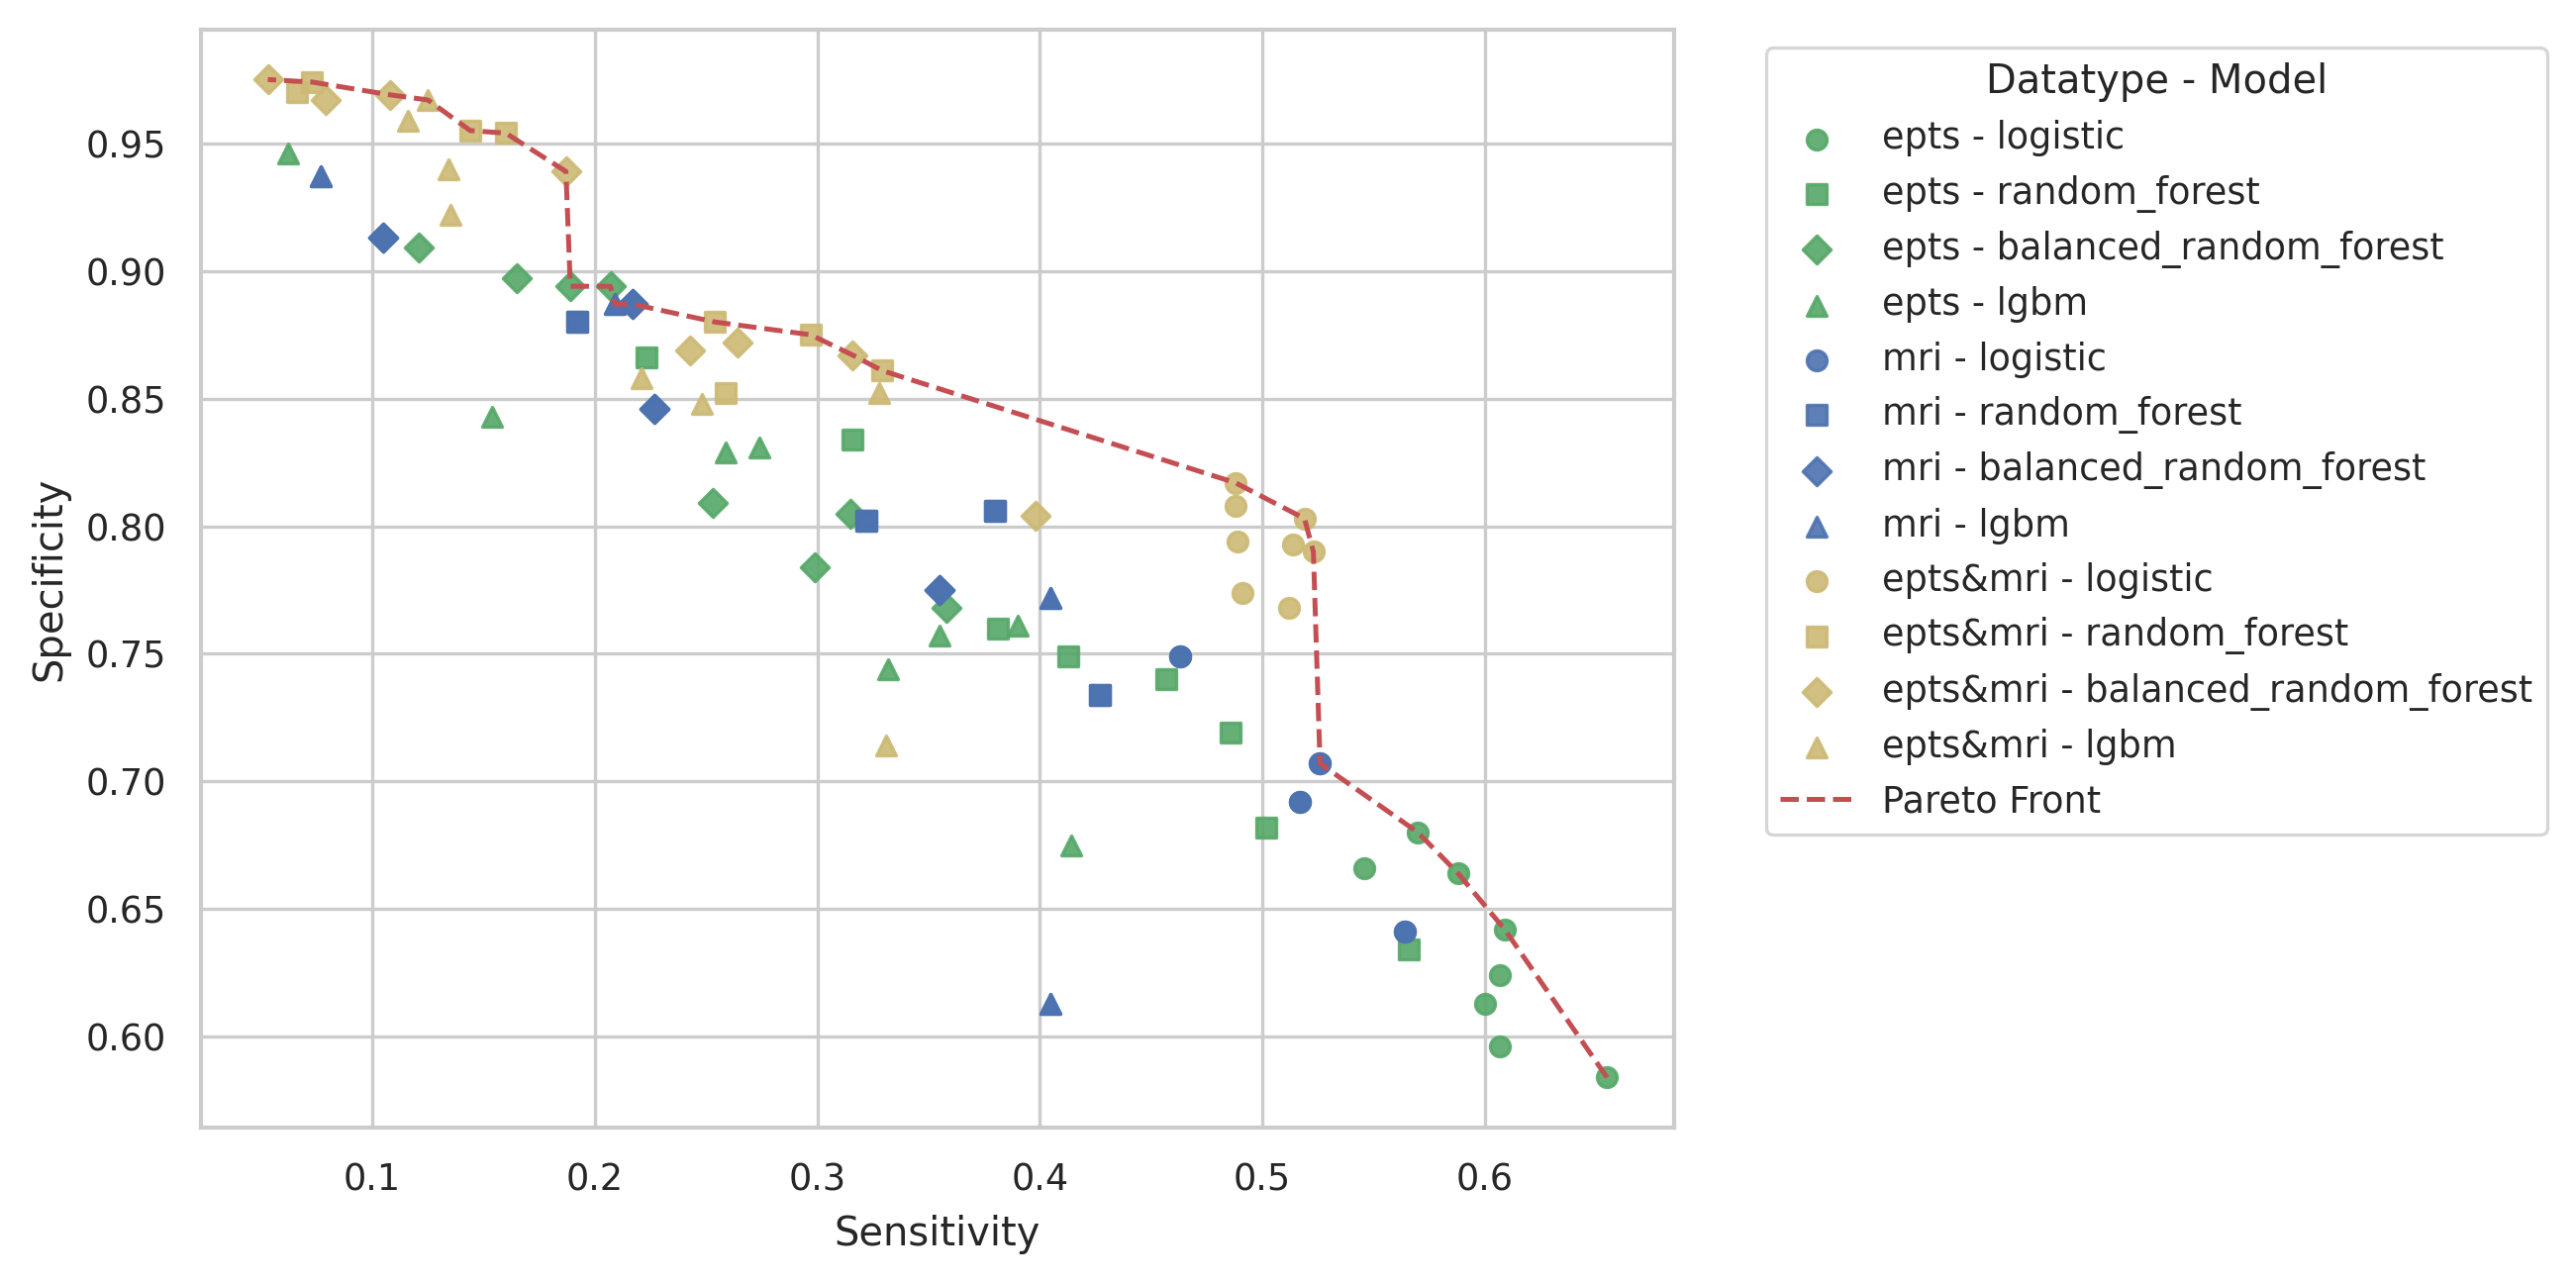

In [3]:
import seaborn as sns
sns.set(style='whitegrid')
sns.set_context('paper')
from matplotlib import pyplot as plt

def pareto_frontier(Xs, Ys, maxX=True, maxY=True):
    sorted_list = sorted([[Xs[i], Ys[i]] for i in range(len(Xs))], reverse=maxX)
    frontier = [sorted_list[0]]
    for pair in sorted_list[1:]:
        if maxY:
            if pair[1] >= frontier[-1][1]:
                frontier.append(pair)
        else:
            if pair[1] <= frontier[-1][1]:
                frontier.append(pair)
    return frontier

def make_scatterplot(result_df, x_var, y_var, x_name, y_name):
    fig, ax = plt.subplots()

    markers = ['x', 'o', 'D', '^', 'v', '<', '>', 'p', 'h']
    colors = ['g', 'b', 'y', 'c', 'm', 'y', 'k', 'w']

    for i, datatype in enumerate(pd.unique(result_df['data'])):
        datatype_df = result_df[result_df['data'] == datatype]
        for model in ['logistic', 'random_forest', 'balanced_random_forest', 'lgbm']:
            model_df = datatype_df[datatype_df['model'] == model]
            marker = 'o' if model == 'logistic' else (
            's' if model == 'random_forest' else (
            'D' if model == 'balanced_random_forest' else '^'))
            plt.scatter(model_df[x_var], model_df[y_var], label=f'{datatype} - {model}', marker=marker, alpha=0.9, color=colors[i])

    pareto_front = pareto_frontier(result_df[x_var], result_df[y_var], maxX=True, maxY=True)
    pareto_frontier_x = [x for x, y in pareto_front]
    pareto_frontier_y = [y for x, y in pareto_front]
    plt.plot(pareto_frontier_x, pareto_frontier_y, label='Pareto Front', color='r', linestyle='--')
    plt.xlabel(x_name)
    plt.ylabel(y_name)
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), title='Datatype - Model', bbox_to_anchor=(1.05, 1), loc='upper left')

make_scatterplot(result_df, 'sensitivity', 'specificity', 'Sensitivity', 'Specificity')

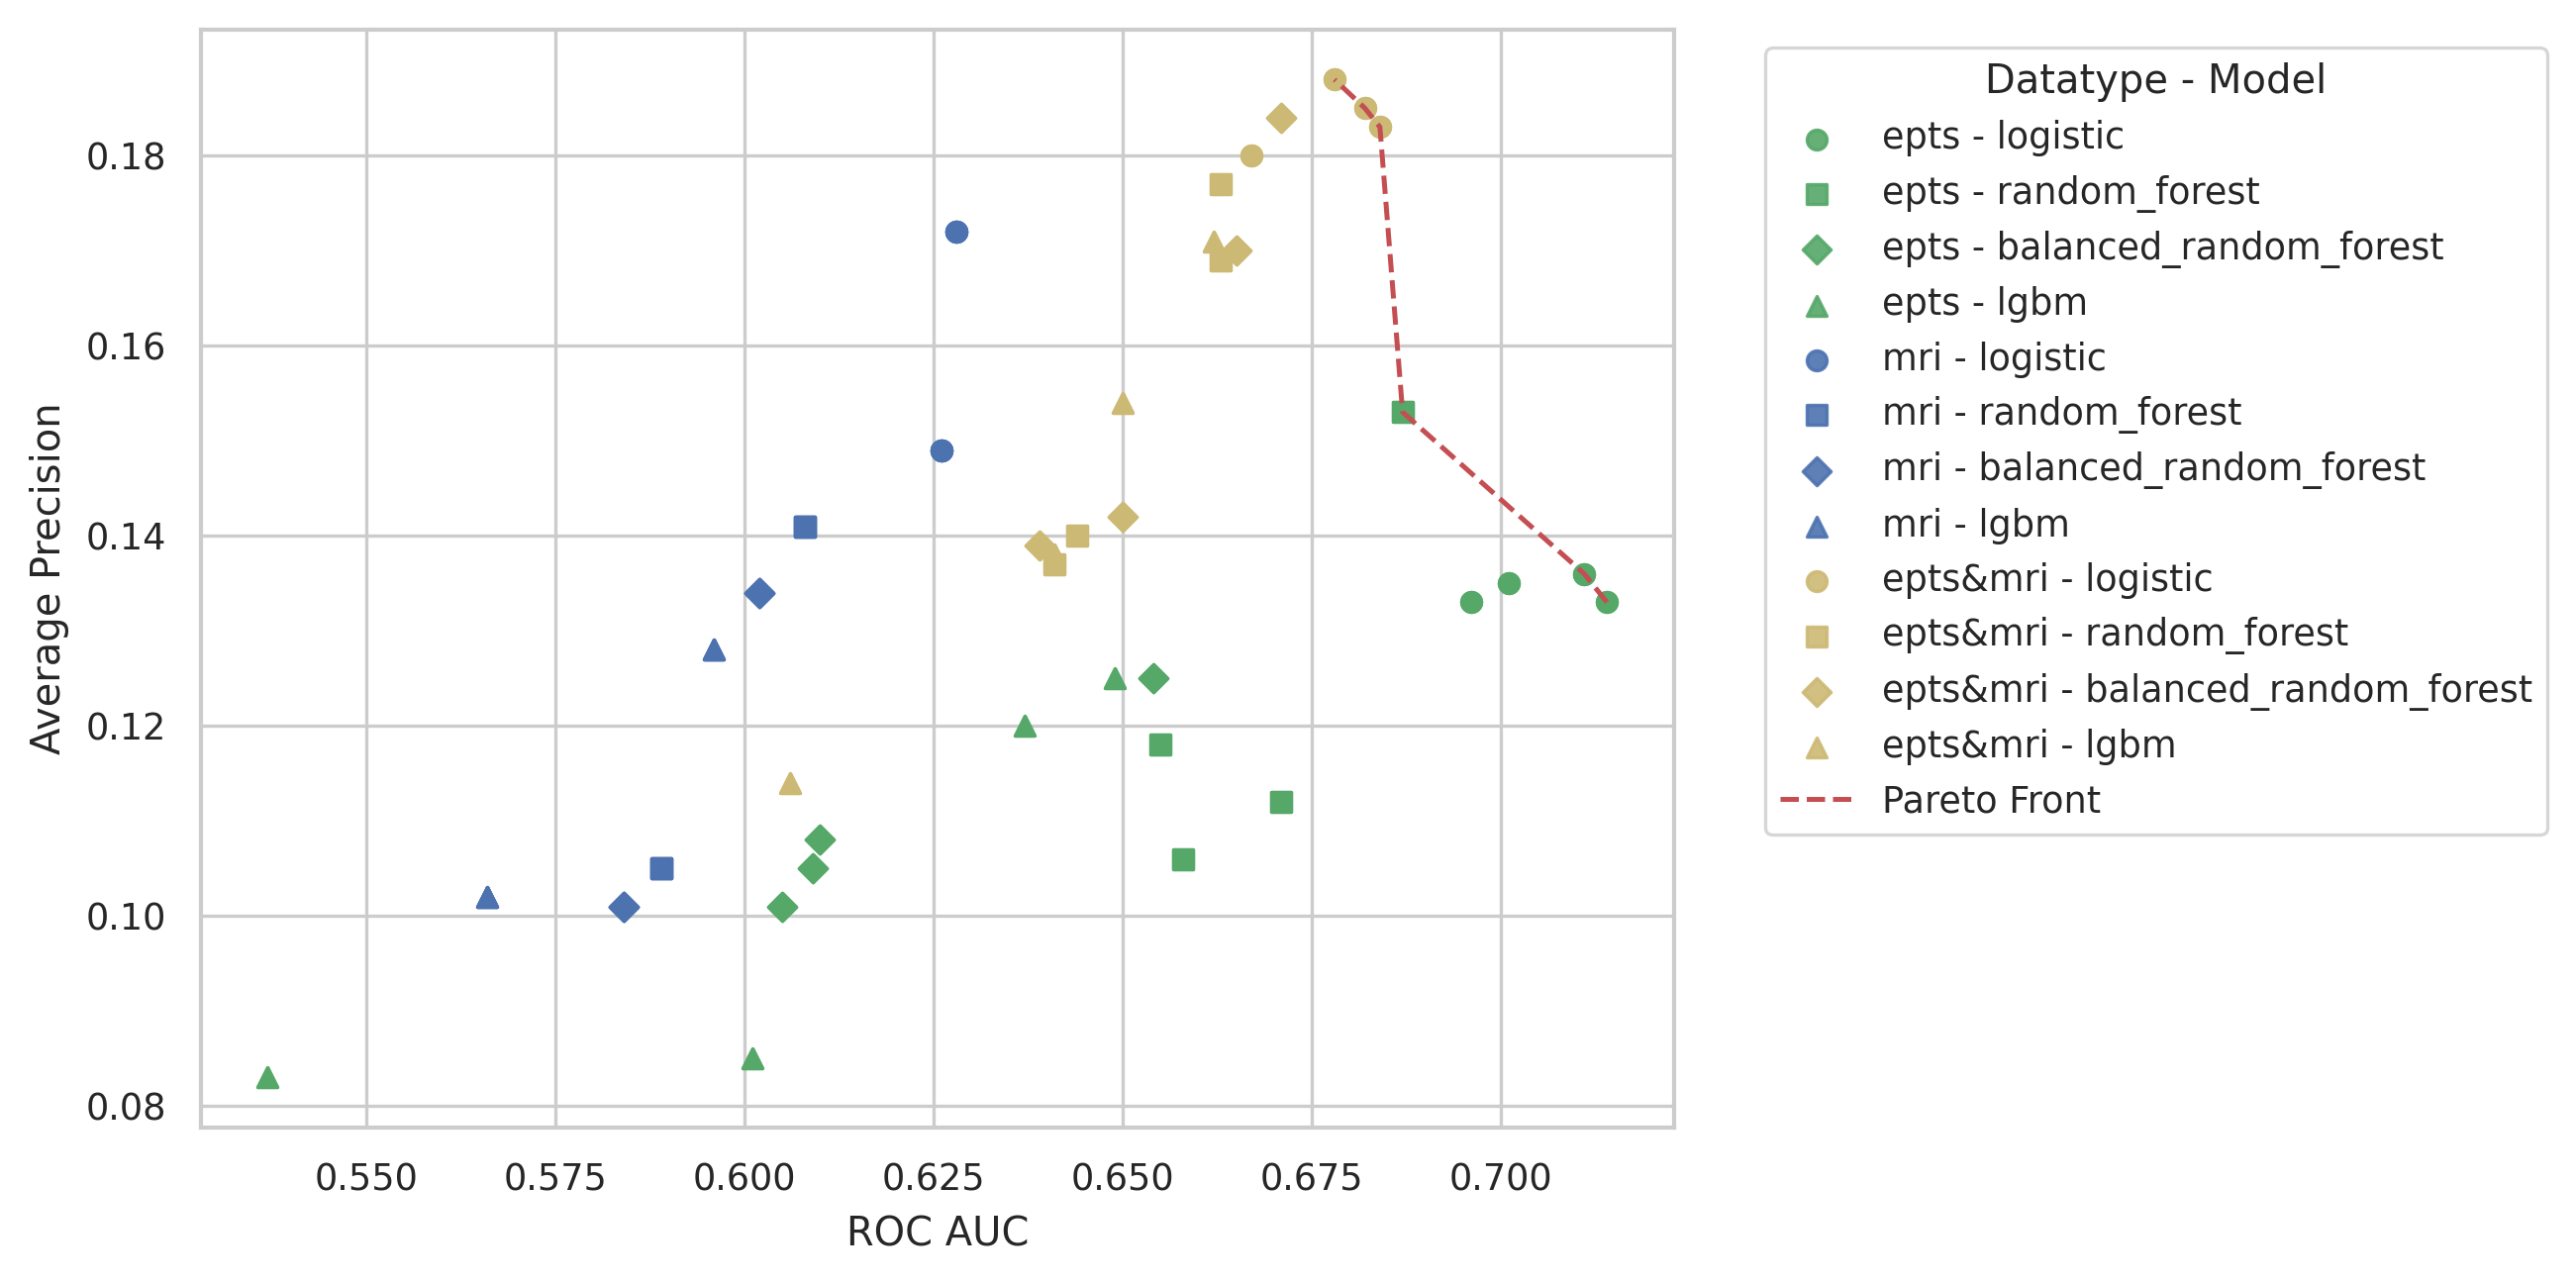

In [4]:
make_scatterplot(result_df, 'roc_auc', 'aupr', 'ROC AUC', 'Average Precision')

# Figure 6: Comparison of model performances

In [5]:
from glob import glob
import pandas as pd

final_df = pd.DataFrame()

results_dir = 'results_20250205_gitid_b63477ee0a3254b7b6b7b7d0e59640d36ce58087'

for folder in sorted(glob(f'{results_dir}/*')):
    datatype = folder.split('(')[1].split(')')[0].replace("'", '').replace(', ', ' & ').replace(',', '')
    experiment = folder.split('/')[-1]
    # This is an identifier without the data part
    experiment = experiment.split('(')[0]+experiment.split(')')[1]

    try:
        pf_df = pd.read_csv(folder + '/per_fold_metrics.csv').iloc[:,:-1]
        # pf_df = pf_df.iloc[:3]
    except:
        continue
    pf_df['data'] = datatype
    pf_df['experiment'] = experiment
    final_df = pd.concat([final_df, pf_df], ignore_index=True)

# Only keep the experiments that have 180 rows
# final_df = final_df[final_df.groupby('experiment').experiment.transform('count') == 180]
final_df

,accuracy,f1,log_loss,geometric_mean,roc_auc,aupr,sensitivity,specificity,brier,mcc,data,experiment
0,0.500000,0.000000,0.258143,0.000000,0.866197,0.139421,0.000000,1.000000,0.064172,0.000000,epts & mri,balanced_random_forest_
1,0.547980,0.166667,0.242291,0.330798,0.639731,0.230334,0.111111,0.984848,0.059495,0.162554,epts & mri,balanced_random_forest_
2,0.605469,0.266667,0.287342,0.490137,0.717773,0.149818,0.250000,0.960938,0.080559,0.224626,epts & mri,balanced_random_forest_
3,0.496774,0.000000,0.232726,0.000000,0.639516,0.089939,0.000000,0.993548,0.058759,-0.017849,epts & mri,balanced_random_forest_
4,0.500000,0.000000,0.356582,0.000000,0.540909,0.064922,0.000000,1.000000,0.103893,0.000000,epts & mri,balanced_random_forest_
...,...,...,...,...,...,...,...,...,...,...,...,...
5755,0.422131,0.000000,0.439043,0.000000,0.551230,0.072082,0.000000,0.844262,0.139137,-0.105945,mri,random_forest__sum_epts_includeclinical
5756,0.534959,0.090909,0.487443,0.417114,0.556098,0.079003,0.200000,0.869919,0.158806,0.039916,mri,random_forest__sum_epts_includeclinical
5757,0.492857,0.000000,0.310012,0.000000,0.680952,0.159468,0.000000,0.985714,0.084889,-0.029574,mri,random_forest__sum_epts_includeclinical
5758,0.476000,0.000000,0.343896,0.000000,0.547000,0.082756,0.000000,0.952000,0.098155,-0.054987,mri,random_forest__sum_epts_includeclinical


In [6]:
from scikit_posthocs import posthoc_nemenyi
from scipy import stats

from sklearn.preprocessing import MinMaxScaler

copy_df = final_df.copy()
# Higher is better columns
for m in ['log_loss', 'brier']:
    copy_df[m] = 1 - copy_df[m]
copy_df.iloc[:,:-2] = MinMaxScaler().fit_transform(final_df.iloc[:,:-2])
copy_df = copy_df.melt(id_vars=['data', 'experiment'], var_name='metric', value_name='score')
print(copy_df)

res = stats.friedmanchisquare(*[copy_df[copy_df['data'] == datatype]['score'] for datatype in pd.unique(copy_df['data'])])
print(res)

for metric in final_df.columns[:-2]:
    # Skip standard deviations
    if metric[-4:] == '_std':
        continue

    print('='*80)
    print(metric)
    groups = [final_df[final_df['data'] == datatype][metric] for datatype in pd.unique(final_df['data'])]


    res = stats.friedmanchisquare(*groups)
    if res.pvalue > 0.05:
        print('Friedman test NOT significant')
        continue


    with pd.option_context('display.float_format', '{:,.3f}'.format):
        print(posthoc_nemenyi(final_df, val_col=metric, group_col='data'))
    

             data                               experiment    metric     score
0      epts & mri                  balanced_random_forest_  accuracy  0.327242
1      epts & mri                  balanced_random_forest_  accuracy  0.398860
2      epts & mri                  balanced_random_forest_  accuracy  0.484673
3      epts & mri                  balanced_random_forest_  accuracy  0.322427
4      epts & mri                  balanced_random_forest_  accuracy  0.327242
...           ...                                      ...       ...       ...
57595         mri  random_forest__sum_epts_includeclinical       mcc  0.077602
57596         mri  random_forest__sum_epts_includeclinical       mcc  0.244603
57597         mri  random_forest__sum_epts_includeclinical       mcc  0.165041
57598         mri  random_forest__sum_epts_includeclinical       mcc  0.135945
57599         mri  random_forest__sum_epts_includeclinical       mcc  0.499735

[57600 rows x 4 columns]
FriedmanchisquareResult(st

In [26]:
import pingouin as pg

print("Significance tests within metrics")

def p_to_stars(p):
    if p < 0.0001:
        return '****'
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return ''

for metric in final_df.columns[:-2]:
    # Skip standard deviations
    if metric[-4:] == '_std':
        continue

    print('='*80)
    print(metric)
    aov = pg.anova(dv=metric, data=final_df, between='data', detailed=True)
    # print(aov)

    if aov['p-unc'][0] > 0.05:
        print('ANOVA NOT significant')
        continue

    mdf = averaged_df.melt(id_vars=['data', 'experiment'], var_name='metric', value_name='value')
    mdf = mdf.groupby(['data', 'experiment', 'metric']).mean().reset_index()
    mdf = mdf[mdf['metric']==metric]
    pt = pg.pairwise_tests(mdf, between='data', dv='value', padjust='bonf', parametric=True)

    for i, row in pt.loc[pt['p-corr'] < 0.05].iterrows():
        stars = p_to_stars(row['p-corr'])
        print(f'{row["A"]} vs {row["B"]}: p={row["p-corr"]:.5f} {stars}')


Significance tests within metrics
accuracy
f1
log_loss
epts vs epts & mri: p=0.00002 ****
epts & mri vs mri: p=0.00073 ***
geometric_mean
roc_auc
epts vs mri: p=0.00000 ****
epts & mri vs mri: p=0.00000 ****
aupr
epts vs epts & mri: p=0.00000 ****
epts & mri vs mri: p=0.00000 ****
sensitivity
epts vs epts & mri: p=0.03561 *
specificity
epts vs epts & mri: p=0.00000 ****
epts & mri vs mri: p=0.00065 ***
brier
epts vs epts & mri: p=0.00001 ****
epts & mri vs mri: p=0.00355 **
mcc
epts vs epts & mri: p=0.01500 *
epts & mri vs mri: p=0.02403 *


Text(0, 0.5, '')

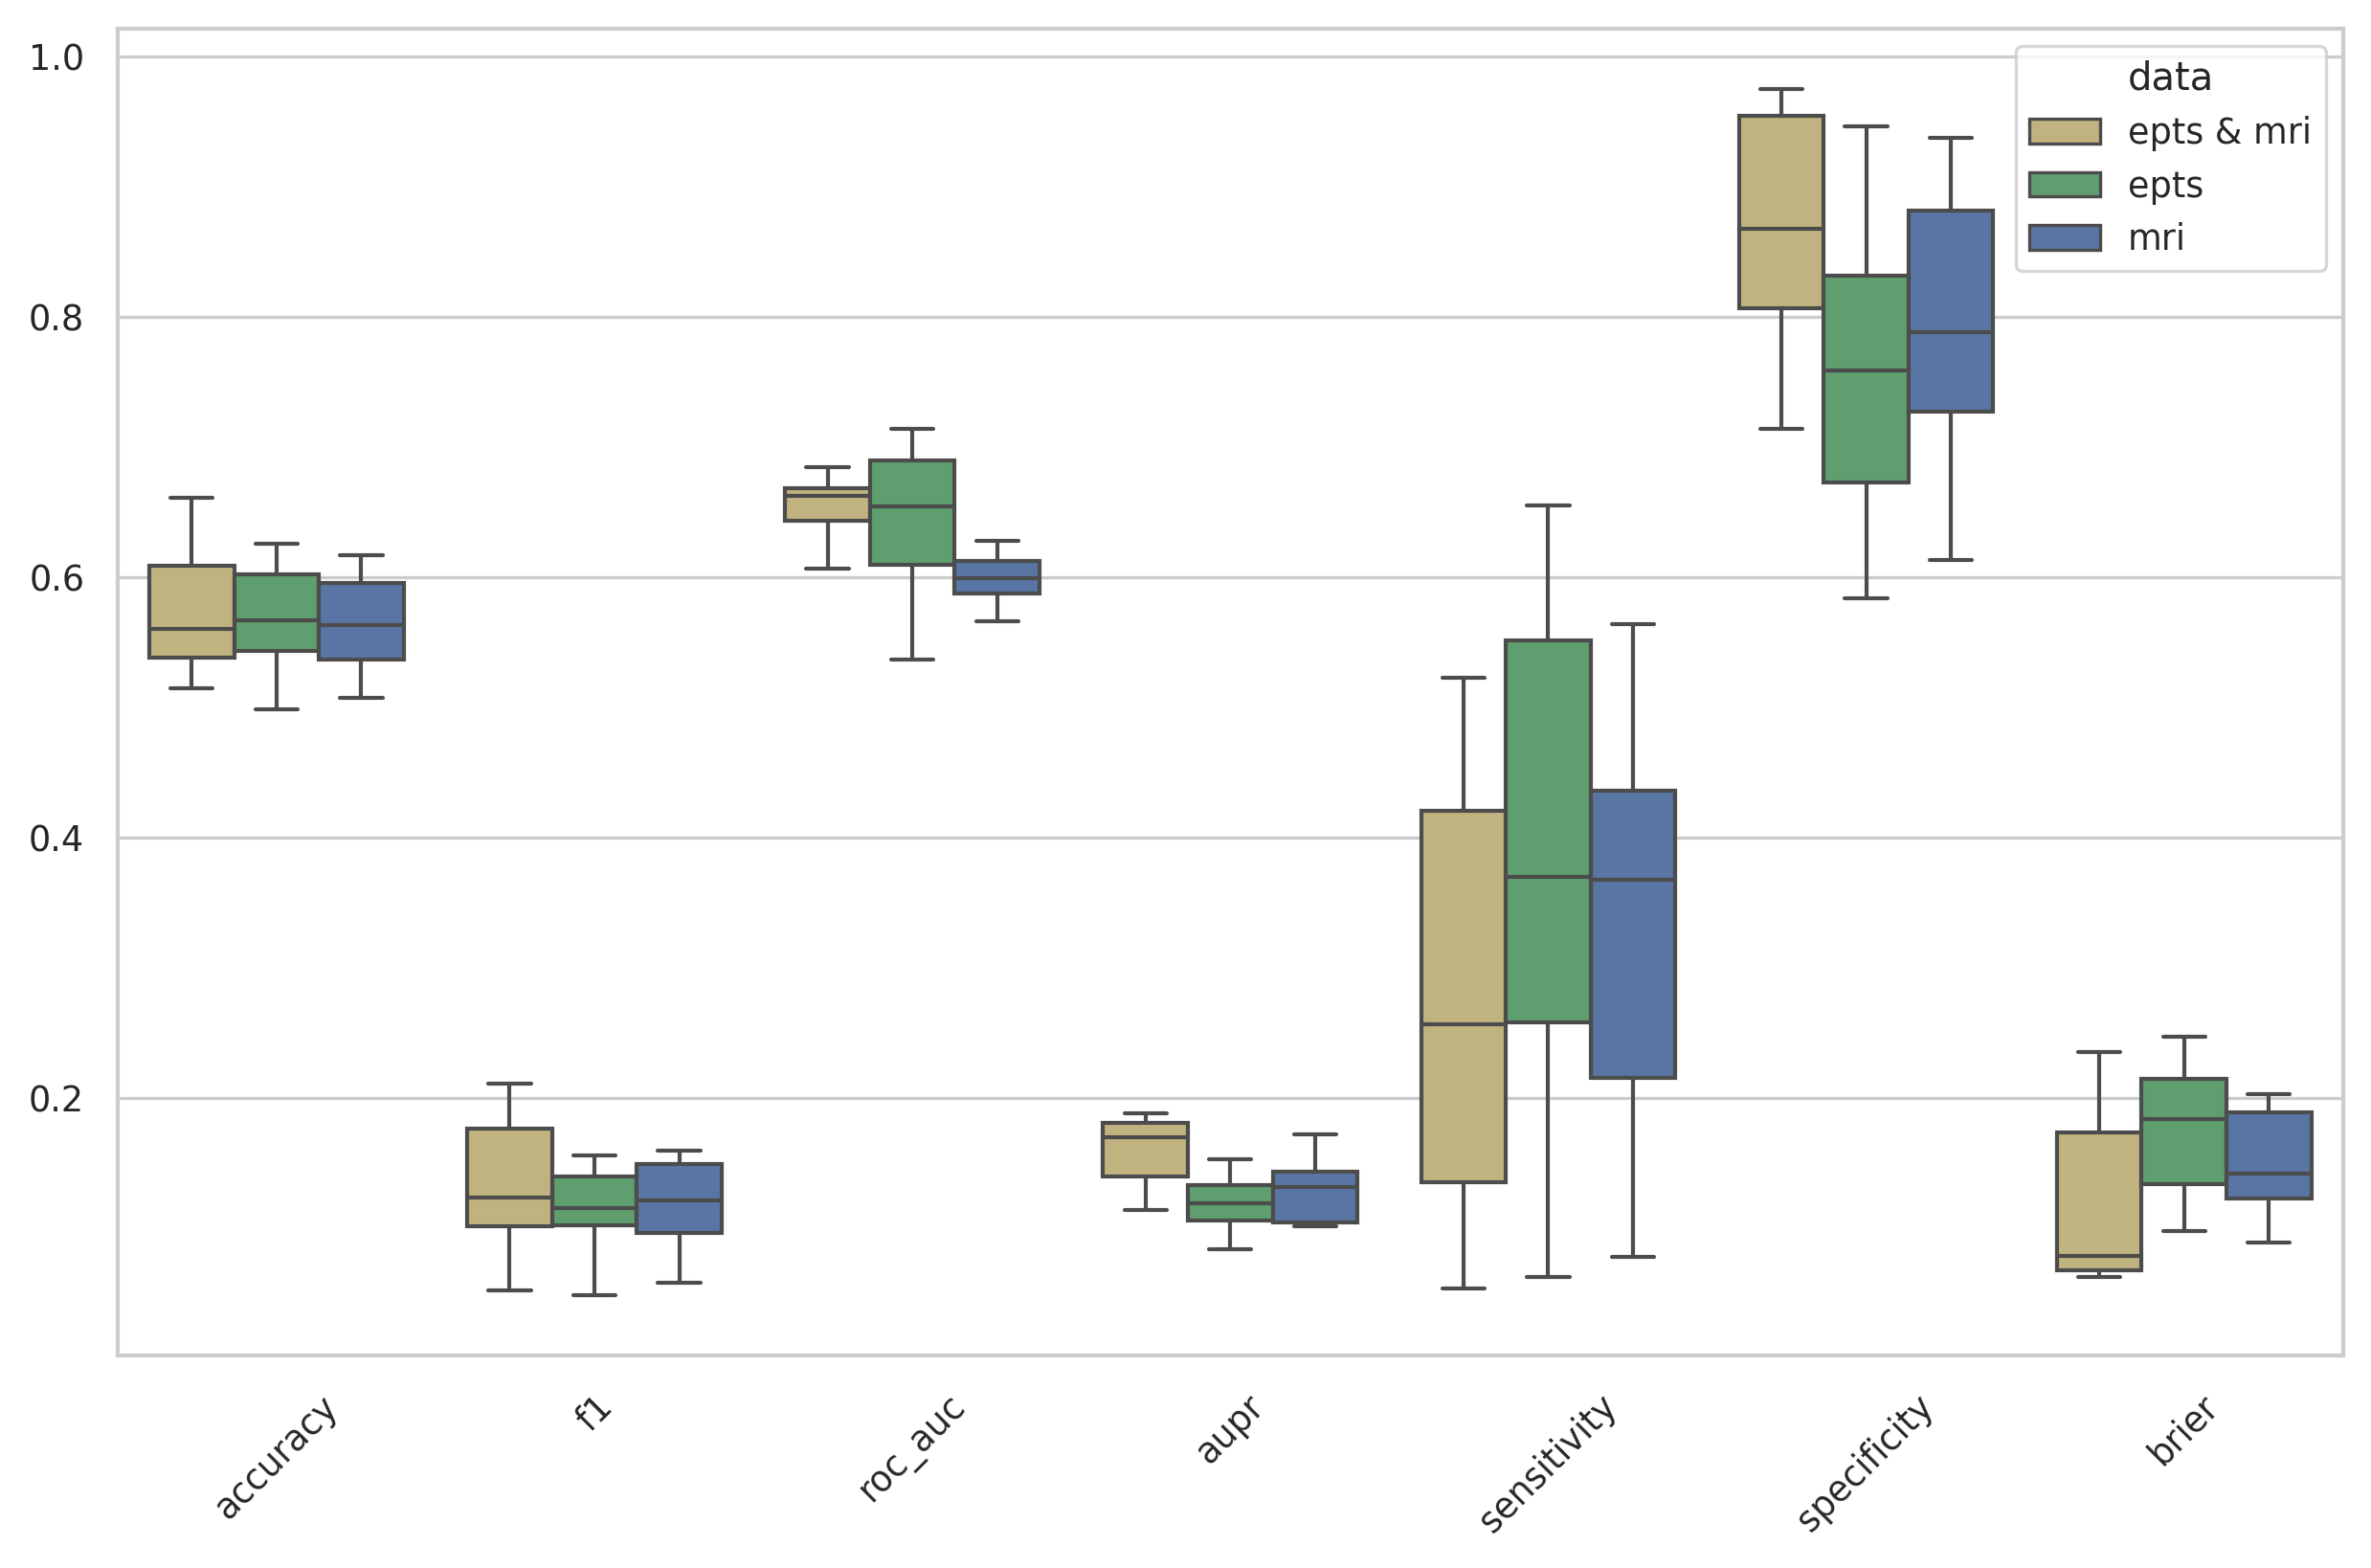

In [33]:
# 1. Average performance for each repeat
# Every three rows are a full cross-validation run, we need to average them
averaged_df = []
for d, rows in final_df.groupby(['data', 'experiment']):
    for i in range(0, len(rows), 3):
        subrows = rows.iloc[i:i+3]
        # Exclude the last two columns from the mean
        mean_row = subrows.iloc[:,:-2].mean()

        # Add the data and experiment columns
        mean_row['data'] = d[0]
        mean_row['experiment'] = d[1]
        averaged_df.append(mean_row)

averaged_df = pd.DataFrame(averaged_df)
averaged_df

melted_df = averaged_df.melt(id_vars=['data', 'experiment'], var_name='metric', value_name='value')
melted_df = melted_df.groupby(['data', 'experiment', 'metric'], sort=False).mean().reset_index()
melted_df = melted_df[melted_df['metric'] != 'log_loss']
melted_df = melted_df[melted_df['metric'] != 'geometric_mean']
melted_df = melted_df[melted_df['metric'] != 'mcc']

# melted_df = melted_df[melted_df['experiment'].str.contains('sum_epts_calibrated')]

palette = {
    'epts & mri': 'y',
    'epts': 'g',
    'mri': 'b',
}
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=melted_df,
    x='metric',
    y='value',
    hue='data',
    palette=palette,
    hue_order=['epts & mri', 'epts', 'mri'],
)
plt.xticks(rotation=45)
plt.xlabel('')
plt.ylabel('')

 # Figure 5: CD Diagram

In [9]:
melted_df['data_and_exp'] = melted_df['data'] + ' ' + melted_df['experiment']

FriedmanchisquareResult(statistic=49.342857142857156, pvalue=1.888502685735811e-09)
data
epts                     0.466667
epts & clinical          0.383333
epts & mri               0.875000
epts & mri & clinical    0.850000
mri                      0.483333
mri & clinical           0.441667
Name: value, dtype: float64
0.39737243533086714


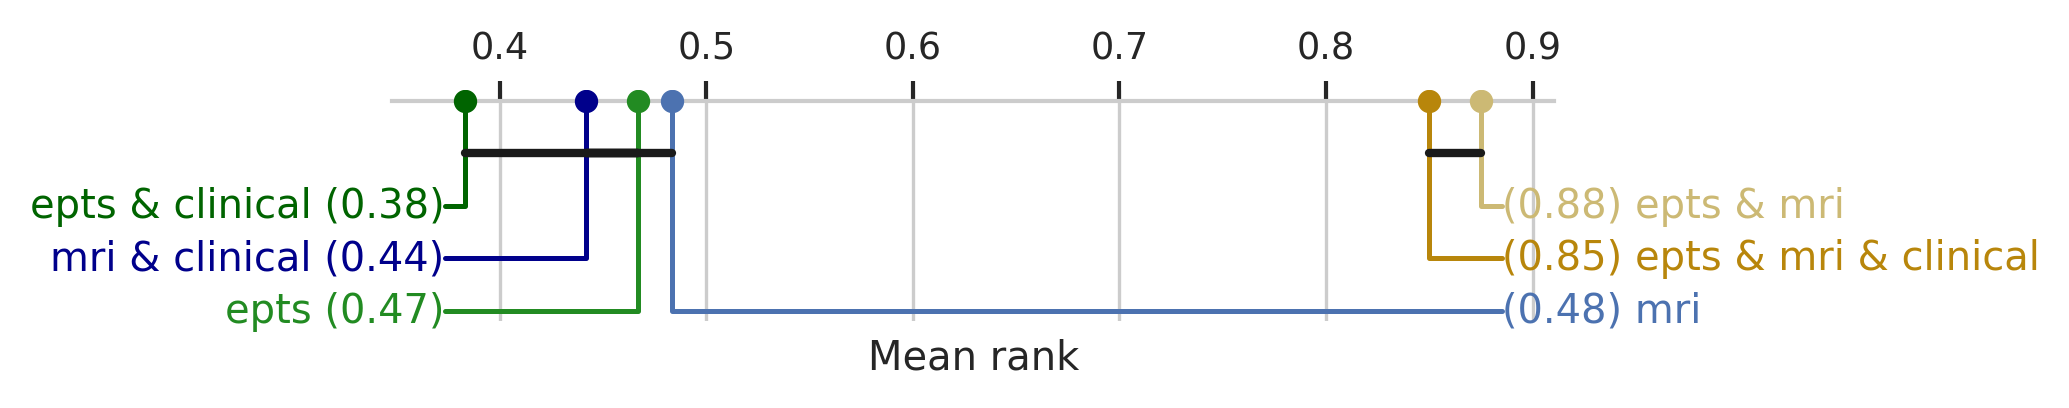

,epts,epts & clinical,epts & mri,epts & mri & clinical,mri,mri & clinical
epts,1.000000,1.000000,0.000210,0.000362,1.000000,1.000000
epts & clinical,1.000000,1.000000,0.000029,0.000029,1.000000,1.000000
epts & mri,0.000210,0.000029,1.000000,1.000000,0.000566,0.000029
epts & mri & clinical,0.000362,0.000029,1.000000,1.000000,0.008133,0.000029
mri,1.000000,1.000000,0.000566,0.008133,1.000000,1.000000
mri & clinical,1.000000,1.000000,0.000029,0.000029,1.000000,1.000000


In [ ]:
import scikit_posthocs as sp

import numpy as np
from scipy.stats import studentized_range, friedmanchisquare


def critical_difference(k, N, alpha=0.05):
    """
    Compute the Critical Difference (CD) for the Nemenyi test.
    
    Parameters:
    k : int    -> Number of classifiers/treatments
    N : int    -> Number of datasets
    alpha : float -> Significance level (default: 0.05)
    
    Returns:
    CD : float -> Critical difference value
    """
    q_alpha = studentized_range.ppf(1 - alpha, k, np.inf)
    CD = q_alpha * np.sqrt((k * (k + 1)) / (6 * N))
    return CD


# add a column with an ascending series per datatype
new_melted_df = melted_df.copy()

new_melted_df['has_clinical'] = new_melted_df['data_and_exp'].str.contains('includeclinical')
new_melted_df['data'] = new_melted_df['data']+new_melted_df['has_clinical'].apply(lambda x: ' & clinical' if x else '')
# new_melted_df = new_melted_df[new_melted_df['metric'].isin(['roc_auc', 'aupr', 'brier'])]


# Make sure that the Brier score is converted to the same scale as the other metrics (higher is better)
for m in ['brier', 'log_loss']:
    new_melted_df.loc[new_melted_df['metric'] == m, 'value'] = -new_melted_df.loc[new_melted_df['metric'] == m, 'value']

for metric_name in pd.unique(new_melted_df['metric']):
    # Normalize the metric
    metric_values = new_melted_df.loc[new_melted_df['metric'] == metric_name, 'value']
    # max_val = metric_values.max()
    # min_val = metric_values.min()
    # new_melted_df.loc[new_melted_df['metric'] == metric_name, 'value'] = (metric_values - min_val) / (max_val - min_val)
    mean_val = metric_values.mean()
    std_val = metric_values.std()
    new_melted_df.loc[new_melted_df['metric'] == metric_name, 'value'] = (metric_values - mean_val) / std_val


new_melted_df['cv_fold'] = new_melted_df.groupby(['data_and_exp', 'metric']).cumcount()

# Construct an average rank for each datatype
avg_rank = []
for i, subdf in new_melted_df.groupby(['cv_fold','data']):
    subdf = subdf.copy()
    best_value = subdf.groupby('experiment')['value'].max().mean()
    avg_rank.append({
        'data': subdf['data'].iloc[0],
        'fold': subdf['cv_fold'].iloc[0],
        'value': best_value 
    })
avg_rank = pd.DataFrame(avg_rank)
df_for_nemenyi = avg_rank.copy()
avg_rank = avg_rank.groupby('fold').value.rank(pct=True).groupby(avg_rank.data).mean()

print(friedmanchisquare(*[df_for_nemenyi[df_for_nemenyi['data'] == datatype]['value'] for datatype in pd.unique(df_for_nemenyi['data'])]))
phnf = sp.posthoc_wilcoxon(
    df_for_nemenyi, val_col='value', group_col='data', p_adjust='holm'
)

plt.figure(figsize=(5, 1))
color_palette = {
    'epts': 'forestgreen',
    'mri': 'b',
    'epts & mri': 'y',
    'epts & mri & clinical': 'darkgoldenrod', 
    'epts & clinical': 'darkgreen', 
    'mri & clinical': 'darkblue'
}

assert np.all(phnf.columns == avg_rank.index)
assert np.all(phnf.index == avg_rank.index)

print(avg_rank)
sp.critical_difference_diagram(
    avg_rank.squeeze(),
    phnf*5,
    color_palette=color_palette
)
plt.xlabel('Mean rank')
CD = critical_difference(6, 20)/6
print(CD)
plt.show()
phnf
